## Part 1 — Install Libraries

In [ ]:
!pip install -q langchain langchain-community langchain-groq langchain-huggingface langchain-text-splitters
!pip install -q faiss-cpu sentence-transformers kagglehub pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 69.5 MB/s eta 0:00:00


In [ ]:
import warnings; warnings.filterwarnings("ignore", category=DeprecationWarning)
import langchain, faiss, sentence_transformers, kagglehub, pandas as pd
import matplotlib.pyplot as plt
NAVY, BLUE, AMBER, GREEN = "#1F3864", "#2E74B5", "#BF9000", "#548235"
print("✅ Libraries ready | langchain", langchain.__version__)

✅ Libraries ready | langchain 1.3.17


### Part 1b — Graph Theme

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

NAVY, BLUE, AMBER, GREEN, RED = "#1F3864", "#2E74B5", "#BF9000", "#548235", "#C00000"
PALETTE = [BLUE, GREEN, AMBER, "#8E44AD", RED, "#17A2B8"]

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "figure.facecolor": "white", "figure.autolayout": True,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#CFD8E3", "axes.linewidth": 1.0,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#E6EBF1", "grid.linewidth": 0.9,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "legend.frameon": False, "legend.fontsize": 9.5,
})
print("Graph theme applied — all charts below now are in styling.")

✅ Graph theme applied — all charts below now are in styling.


## Part 2 — API Key Setup
Groq API key Setup

In [ ]:
import os
GROQ_API_KEY = "YOUR_GROQ_API_KEY_HERE"

if not GROQ_API_KEY.strip():
    import getpass
    GROQ_API_KEY = getpass.getpass("Paste your Groq API key (hidden): ").strip()
assert GROQ_API_KEY.startswith("gsk_"), "That does not look like a Groq key"
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
print("✅ Groq API key set")

✅ Groq API key set


## Part 3 — Download the MedQuAD Dataset

In [ ]:
import kagglehub, os, glob
DATA_PATH = kagglehub.dataset_download("pythonafroz/medquad-medical-question-answer-for-ai-research")
print("Dataset at:", DATA_PATH)
for f in glob.glob(DATA_PATH + "/**/*", recursive=True):
    if os.path.isfile(f): print(" •", os.path.basename(f), f"({os.path.getsize(f)//1024} KB)")

100%|██████████| 4.95M/4.95M [00:00<00:00, 7.05MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/versions/1
 • medquad.csv (22300 KB)


## Part 4 — Load and Clean the Data

In [ ]:
import pandas as pd, glob

csv_files = glob.glob(DATA_PATH + "/**/*.csv", recursive=True)
df_raw = pd.read_csv(csv_files[0])
qcol = next(c for c in df_raw.columns if 'question' in c.lower())
acol = next(c for c in df_raw.columns if 'answer'  in c.lower())
extra_cols = [c for c in df_raw.columns
              if any(k in c.lower() for k in ('source','focus','type')) and c not in (qcol, acol)]

df = df_raw[[qcol, acol] + extra_cols].copy()
df.columns = ['question', 'answer'] + [c.lower().replace(' ', '_') for c in extra_cols]
before = len(df)
df = df.dropna(subset=['question','answer'])
df['question'] = df['question'].astype(str).str.strip()
df['answer']   = df['answer'].astype(str).str.strip()
df = df[df['answer'].str.len() >= 30]
df = df[df['question'].str.len() >= 10]
df = df.drop_duplicates(subset=['question','answer'])
df['answer'] = df['answer'].str.slice(0, 6000)
df = df.reset_index(drop=True)
print(f"Cleaning: {before:,} → {len(df):,} rows")
df.head(3)

Cleaning: 16,412 → 16,357 rows


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma


## Part 5 — Explore the Data

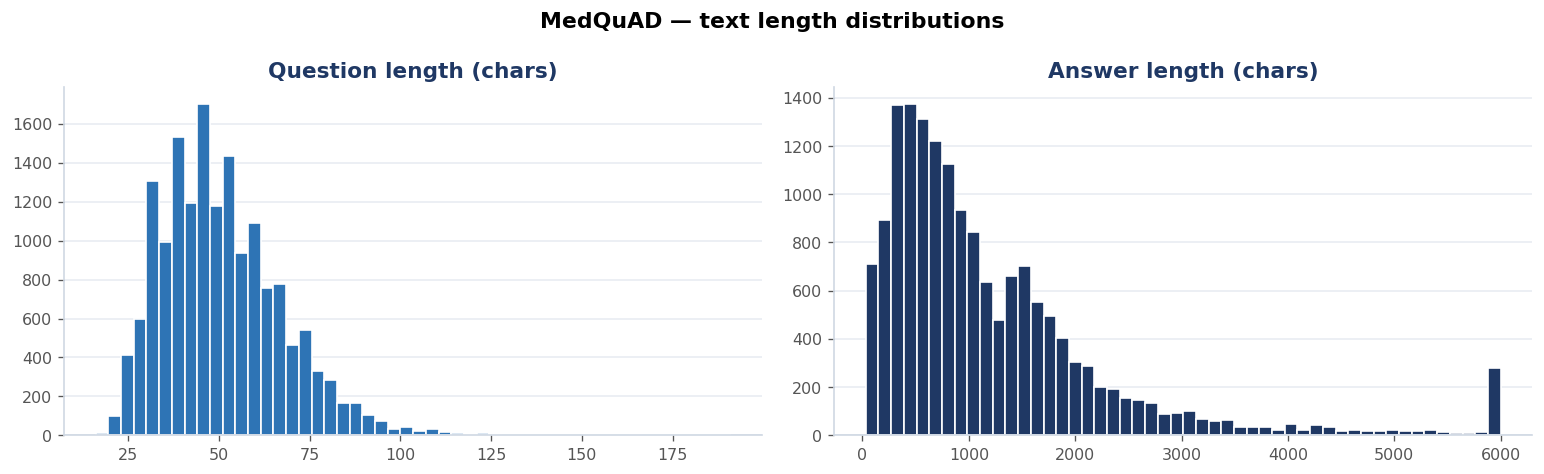

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['question'].str.len(), bins=50, color=BLUE, edgecolor='white')
axes[0].set_title("Question length (chars)", fontweight='bold', color=NAVY)
axes[1].hist(df['answer'].str.len(), bins=50, color=NAVY, edgecolor='white')
axes[1].set_title("Answer length (chars)", fontweight='bold', color=NAVY)
plt.suptitle("MedQuAD — text length distributions", fontweight='bold'); plt.tight_layout(); plt.show()

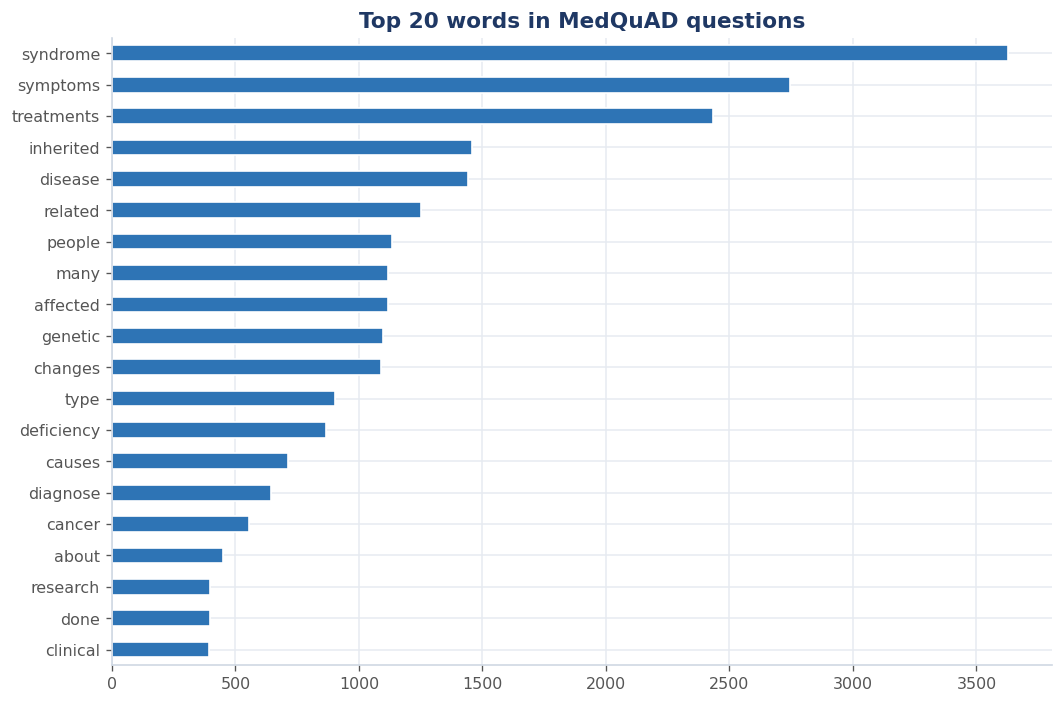

In [ ]:
from collections import Counter
import re as _re
stop = set(('what are the of a an is for to in and how do does can you i my with on or '
            'who where when why which be this that it as at by from').split())
words = Counter(w for q in df['question'].str.lower()
                for w in _re.findall(r'[a-z]{3,}', q) if w not in stop)
pd.Series(dict(words.most_common(20))).iloc[::-1].plot(
    kind='barh', figsize=(9,6), color=BLUE, edgecolor='white')
plt.title("Top 20 words in MedQuAD questions", fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show()

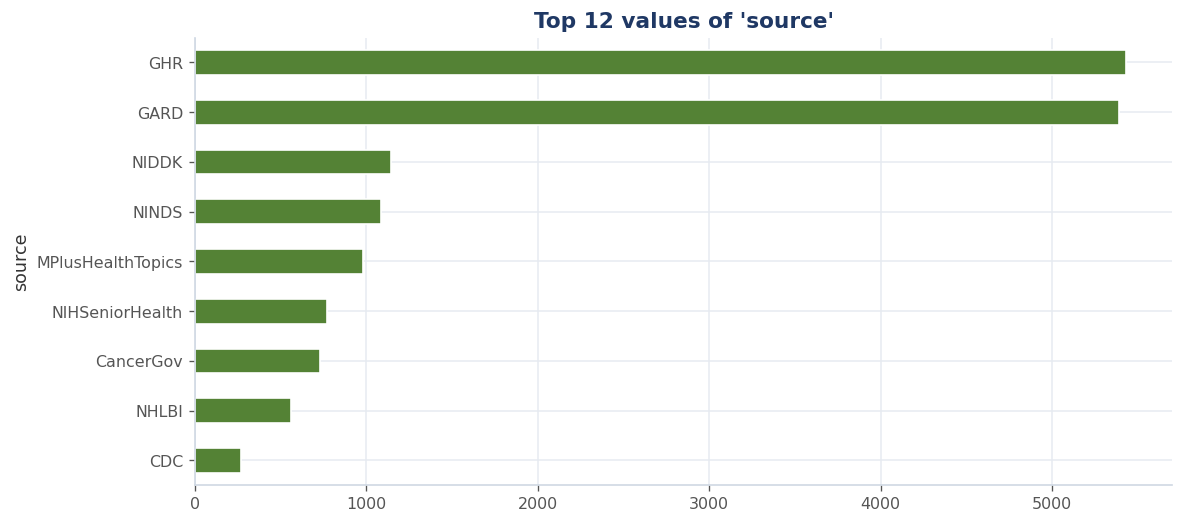

,Metric,Value
0,Q&A pairs,"16,357"
1,Avg question len,50 chars
2,Avg answer len,1218 chars


In [ ]:
meta_col = next((c for c in df.columns if c not in ('question','answer')), None)
if meta_col:
    df[meta_col].value_counts().head(12).iloc[::-1].plot(
        kind='barh', figsize=(10,4.5), color=GREEN, edgecolor='white')
    plt.title(f"Top 12 values of '{meta_col}'", fontweight='bold', color=NAVY)
    plt.tight_layout(); plt.show()
display(pd.DataFrame({"Metric":["Q&A pairs","Avg question len","Avg answer len"],
    "Value":[f"{len(df):,}", f"{int(df['question'].str.len().mean())} chars",
             f"{int(df['answer'].str.len().mean())} chars"]}))

## Part 6 — Build the Retrieval Units

16,257 parent Q&A pairs → 69,515 search keys (16,257 questions + 53,258 fragments)


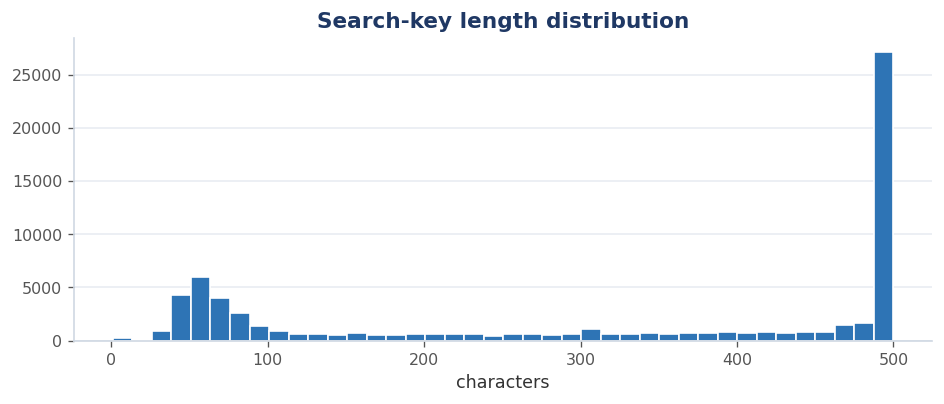

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

HOLDOUT_N = 100
df_eval  = df.sample(n=HOLDOUT_N, random_state=42)
df_index = df.drop(df_eval.index).reset_index(drop=True)

meta_col = next((c for c in df.columns if c not in ('question','answer')), None)

# PARENTS: the complete Q&A pairs the model will actually read
PARENTS = []
for i, r in df_index.iterrows():
    PARENTS.append({
        "question": r['question'],
        "answer":   r['answer'],
        "source":   f"MedQuAD row {i}" + (f" — {r[meta_col]}" if meta_col and pd.notna(r[meta_col]) else "")})

# SEARCH KEYS: texts we embed, each tagged with its parent id
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
key_texts, key_metas = [], []
for pid, p in enumerate(PARENTS):
    key_texts.append("Question: " + p['question'])          # key type 1: the question
    key_metas.append({"pid": pid, "kind": "question"})
    for frag in splitter.split_text(p['answer']):            # key type 2: answer fragments
        key_texts.append(frag)
        key_metas.append({"pid": pid, "kind": "fragment"})

print(f"{len(PARENTS):,} parent Q&A pairs → {len(key_texts):,} search keys "
      f"({sum(1 for m in key_metas if m['kind']=='question'):,} questions + "
      f"{sum(1 for m in key_metas if m['kind']=='fragment'):,} fragments)")

plt.figure(figsize=(8,3.5))
plt.hist([len(t) for t in key_texts], bins=40, color=BLUE, edgecolor='white')
plt.title("Search-key length distribution", fontweight='bold', color=NAVY)
plt.xlabel("characters"); plt.tight_layout(); plt.show()

## Part 7 — Embeddings + FAISS Index

In [ ]:
import torch
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding on:", device.upper())
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": device},
    encode_kwargs={"batch_size": 128, "normalize_embeddings": True})
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

Embedding on: CUDA


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Part 7a — Reuse the saved index from Google Drive
first full run builds the index once and saves it to `My Drive/Final Project/rag_assets`. Every later session **loads it in seconds instead of re-embedding for minutes**.

In [ ]:
# Try to LOAD the saved index + parents from Google Drive (skips rebuilding)
import os, shutil, pickle
from google.colab import drive

DRIVE_DIR = "/content/drive/MyDrive/Final Project/rag_assets"
INDEX_LOADED_FROM_DRIVE = False

try:
    drive.mount("/content/drive")
    if os.path.isdir(DRIVE_DIR + "/faiss_index_medquad") and os.path.exists(DRIVE_DIR + "/parents.pkl"):
        # copy to the local session (fast) so every later cell finds the same paths
        shutil.copytree(DRIVE_DIR + "/faiss_index_medquad", "faiss_index_medquad", dirs_exist_ok=True)
        shutil.copy(DRIVE_DIR + "/parents.pkl", "parents.pkl")

        from langchain_community.vectorstores import FAISS
        index = FAISS.load_local("faiss_index_medquad", embeddings,
                                 allow_dangerous_deserialization=True)
        with open("parents.pkl", "rb") as f:
            PARENTS = pickle.load(f)          # use the SAME parents the index was built with
        INDEX_LOADED_FROM_DRIVE = True
        print(f"✅ Reused saved index from Drive — {index.index.ntotal:,} vectors, "
              f"{len(PARENTS):,} parents. Rebuild will be skipped.")
    else:
        print("ℹ️ No saved index in Drive yet — it will be built once and saved (next cells).")
except Exception as e:
    print("ℹ️ Drive not available — building locally this session. (", e, ")")

Mounted at /content/drive
✅ Reused saved index from Drive — 69,515 vectors, 16,257 parents. Rebuild will be skipped.


In [ ]:
%%time
import warnings; warnings.filterwarnings("ignore", category=DeprecationWarning)
from langchain_community.vectorstores import FAISS
import pickle

if globals().get("INDEX_LOADED_FROM_DRIVE"):
    print("⏭️  Index already loaded from Google Drive — rebuild skipped.")
else:
    index = FAISS.from_texts(key_texts, embeddings, metadatas=key_metas)
    index.save_local("faiss_index_medquad")
    with open("parents.pkl", "wb") as f: pickle.dump(PARENTS, f)   # needed by the GUI later
    print(f"✅ Index built — {index.index.ntotal:,} vectors | parents saved")

⏭️  Index already loaded from Google Drive — rebuild skipped.
CPU times: user 179 µs, sys: 21 µs, total: 200 µs
Wall time: 187 µs


### Part 7b — Save the index to Google Drive (reused next session)

In [ ]:
# Save index + parents to Drive so future sessions skip the rebuild
import os, shutil
DRIVE_DIR = "/content/drive/MyDrive/Final Project/rag_assets"
try:
    if not globals().get("INDEX_LOADED_FROM_DRIVE"):
        os.makedirs(DRIVE_DIR, exist_ok=True)
        shutil.copytree("faiss_index_medquad", DRIVE_DIR + "/faiss_index_medquad", dirs_exist_ok=True)
        shutil.copy("parents.pkl", DRIVE_DIR + "/parents.pkl")
        print("✅ Index + parents saved to:", DRIVE_DIR)
    else:
        print("⏭️  Loaded from Drive — nothing to save.")
except Exception as e:
    print("ℹ️ Could not save to Drive (is it mounted?):", e)

⏭️  Loaded from Drive — nothing to save.


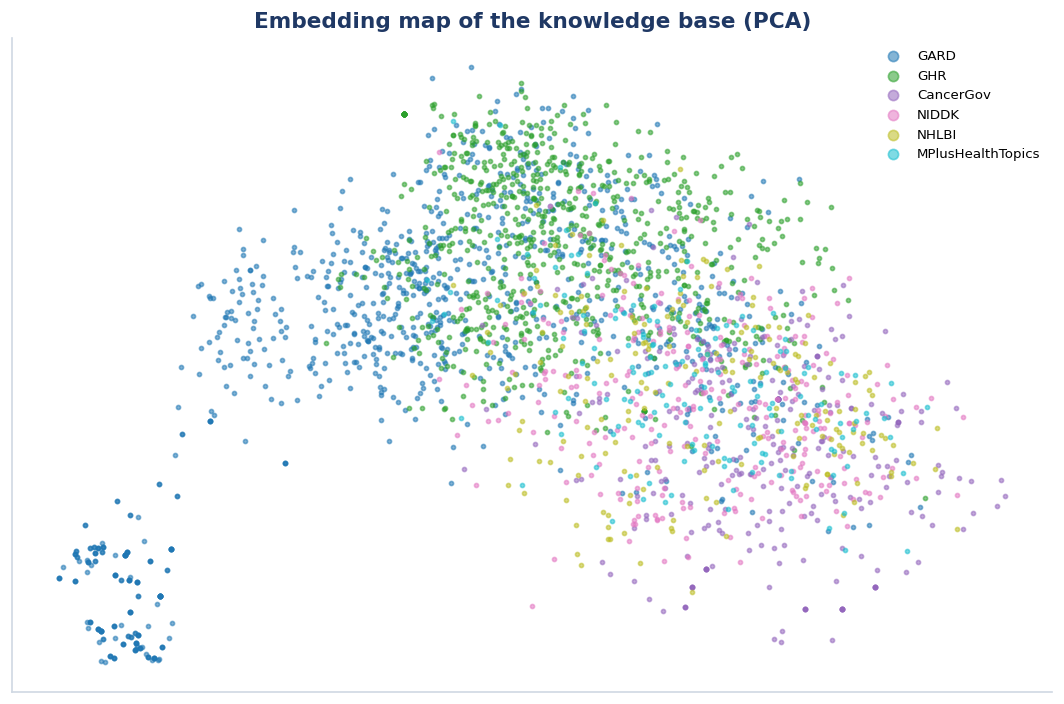

In [ ]:
# GRAPH: 2-D embedding map of the knowledge base (PCA)
import numpy as np
from sklearn.decomposition import PCA

sample_n = min(3000, len(key_texts))
sel = np.random.default_rng(42).choice(len(key_texts), size=sample_n, replace=False)
vecs = st_model.encode([key_texts[i] for i in sel], batch_size=128,
                       normalize_embeddings=True, show_progress_bar=False)
xy = PCA(n_components=2, random_state=42).fit_transform(vecs)
cats = [PARENTS[key_metas[i]['pid']]['source'].split('—')[-1].strip() if '—' in PARENTS[key_metas[i]['pid']]['source']
        else 'MedQuAD' for i in sel]
top_cats = pd.Series(cats).value_counts().head(6).index.tolist()
plt.figure(figsize=(9, 6))
for c, col in zip(top_cats, plt.cm.tab10(np.linspace(0,1,len(top_cats)))):
    m = [j for j,x in enumerate(cats) if x==c]
    plt.scatter(xy[m,0], xy[m,1], s=6, alpha=0.55, color=col, label=c[:28])
plt.title("Embedding map of the knowledge base (PCA)", fontweight='bold', color=NAVY)
plt.legend(markerscale=2.5, fontsize=8); plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

## Part 8 — Retrieval + Answer Generation (Groq)
Using **qwen/qwen3.8-27b (2,000,000 tokens/day free)** to avoid the daily limit; auto-falls back to other models if unavailable.

In [ ]:
from langchain_groq import ChatGroq
from sentence_transformers import util
import numpy as np, groq, time

available = sorted(m.id for m in groq.Groq().models.list().data)
print("Available models on your Groq account:", available)
PREFER = ["qwen/qwen3.8-27b", "llama-3.1-8b-instant",
          "llama-3.3-70b-versatile", "openai/gpt-oss-20b"]
GROQ_MODEL = next((m for m in PREFER if m in available),
                  next((m for m in available if "llama" in m.lower() and "guard" not in m.lower()),
                       "openai/gpt-oss-20b"))
print("✅ Using model:", GROQ_MODEL)

K_SEARCH, K_PARENTS, RETR_THRESHOLD, ANSWER_CAP = 14, 3, 0.35, 1000
REFUSAL = "I cannot answer this from the provided documents."

# reasoning_effort must be an EXPLICIT arg (not model_kwargs); only gpt-oss supports it
_extra = {"reasoning_effort": "low"} if GROQ_MODEL.startswith("openai/gpt-oss") else {}
llm_primary = ChatGroq(model=GROQ_MODEL, temperature=0.2, max_tokens=450, **_extra)
llm_sample  = ChatGroq(model=GROQ_MODEL, temperature=0.8, max_tokens=350, **_extra)

def _invoke(llm, prompt, tries=3):
    """Call Groq with backoff; return None on rate/daily limit instead of crashing."""
    for k in range(tries):
        try:
            return llm.invoke(prompt).content.strip()
        except groq.RateLimitError:
            if k == tries - 1:
                print("   ⏳ Groq rate/daily limit reached — continuing with fewer samples.")
                return None
            time.sleep(5 * (k + 1))

def retrieve(question, k_parents=K_PARENTS, k_search=K_SEARCH):
    query = "Question: " + question
    docs = index.similarity_search(query, k=k_search)
    q_vec  = st_model.encode(query, normalize_embeddings=True)
    d_vecs = st_model.encode([d.page_content for d in docs], normalize_embeddings=True)
    sims   = util.cos_sim(q_vec, d_vecs)[0].tolist()
    best = {}
    for d, s in zip(docs, sims):
        pid = d.metadata['pid']
        if s > best.get(pid, -1): best[pid] = s
    ranked = sorted(best.items(), key=lambda x: -x[1])[:k_parents]
    parents = [{**PARENTS[pid], "sim": round(s, 3)} for pid, s in ranked]
    return parents, (parents[0]['sim'] if parents else 0.0)

def build_prompt(question, parents):
    blocks = [f"[Source {i}] (from: {p['source']})\nQ: {p['question']}\nA: {p['answer'][:ANSWER_CAP]}"
              for i, p in enumerate(parents, 1)]
    context = "\n\n".join(blocks)
    return ("You are a careful medical information assistant.\n"
            "Using ONLY the sources below, give a clear, complete answer to the user's question. "
            "Combine information from several sources if that helps. "
            "If the sources cover the topic only partly, answer with what is available and say what is missing. "
            f"Only if none of the sources are relevant, reply exactly: '{REFUSAL}'\n"
            "Never add medical facts that are not in the sources.\n\n"
            f"{context}\n\nUser question: {question}\nAnswer:")

import re as _re
def _clean(txt):
    if not txt: return txt
    txt = _re.sub(r"(?is)<think>.*?</think>", "", txt)   # drop Qwen reasoning
    return txt.replace("<think>", "").replace("</think>", "").strip()

def generate(question, parents, llm):
    return _clean(_invoke(llm, build_prompt(question, parents)))

_p, _s = retrieve("What are the symptoms of high blood pressure?")
print("Top parent:", _p[0]['question'][:70], f"({_p[0]['sim']:.2f})")

Available models on your Groq account: ['allam-2-7b', 'canopylabs/orpheus-arabic-saudi', 'canopylabs/orpheus-v1-english', 'groq/compound', 'groq/compound-mini', 'meta-llama/llama-prompt-guard-2-22m', 'meta-llama/llama-prompt-guard-2-86m', 'openai/gpt-oss-120b', 'openai/gpt-oss-20b', 'openai/gpt-oss-safeguard-20b', 'qwen/qwen3.6-27b', 'qwen/qwen3.8-27b', 'whisper-large-v3', 'whisper-large-v3-turbo']
✅ Using model: qwen/qwen3.8-27b
Top parent: What are the symptoms of High Blood Pressure ? (1.00)


##Part 9 — 3-Component Confidence Score

In [ ]:
import time, numpy as np
N_SAMPLES, CONF_THRESHOLD = 2, 60

def is_refusal(text):
    if not text: return False
    t = text.lower()
    return ("cannot answer" in t) or ("can't answer" in t) or \
           (("not contain" in t or "no information" in t) and len(t) < 220)

def confidence_components(question, parents, primary, n=N_SAMPLES):
    samples = []
    for _ in range(n):
        s = generate(question, parents, llm_sample)
        if s: samples.append(s)
        time.sleep(0.3)
    real = [a for a in ([primary] + samples) if a and not is_refusal(a)]
    top_sim = parents[0]['sim']
    evidence = float(np.clip((top_sim - 0.35) / (0.80 - 0.35), 0, 1))
    context = " ".join(p['answer'][:ANSWER_CAP] for p in parents)[:3000]
    g = util.cos_sim(st_model.encode(primary, normalize_embeddings=True),
                     st_model.encode(context, normalize_embeddings=True))[0][0]
    groundedness = float(np.clip((float(g) - 0.2) / (0.8 - 0.2), 0, 1))
    if len(real) >= 2:
        vecs = st_model.encode(real, normalize_embeddings=True)
        Smat = util.cos_sim(vecs, vecs).numpy(); m = len(real)
        agreement = float((Smat.sum() - m) / (m * (m - 1)))
        final = round(100*(0.60*agreement + 0.25*evidence + 0.15*groundedness), 1)
        return {"confidence": final, "agreement": round(agreement*100,1),
                "evidence": round(evidence*100,1), "groundedness": round(groundedness*100,1)}
    else:
        final = round(100*(0.625*evidence + 0.375*groundedness), 1)
        return {"confidence": final, "agreement": None,
                "evidence": round(evidence*100,1), "groundedness": round(groundedness*100,1)}

print("Confidence scoring ready — N =", N_SAMPLES)

Confidence scoring ready — N = 2


##Part 10 — The Complete Trustworthy `ask()` Function

In [ ]:
def ask(question, show_sources=True):
    print("═"*78); print("❓ QUESTION:", question); print("═"*78)
    parents, top_sim = retrieve(question)
    if top_sim < RETR_THRESHOLD:
        print(f"\n🚫 REFUSED — no relevant information in MedQuAD (best match {top_sim*100:.0f}%).")
        return {"answer": None, "confidence": None, "refused": True, "retrieval_sim": top_sim}
    primary = generate(question, parents, llm_primary)
    if primary is None:
        print("\n⏳ SERVICE BUSY — Groq daily/rate limit reached. Wait a few minutes or use a fresh key.")
        return {"answer": None, "confidence": None, "refused": True, "retrieval_sim": top_sim}
    if is_refusal(primary):
        print("\n🚫 CANNOT ANSWER — the retrieved sources do not contain this specific answer.")
        print("   Closest topic in the dataset:", parents[0]['question'][:80])
        return {"answer": REFUSAL, "confidence": 0.0, "refused": True, "retrieval_sim": top_sim}
    c = confidence_components(question, parents, primary)
    conf = c['confidence']
    ag = c['agreement'] if c['agreement'] is not None else "n/a (rate-limited)"
    print("\n💬 ANSWER:\n" + primary)
    bar = "█"*int(conf//5) + "░"*(20-int(conf//5))
    print(f"\n📊 CONFIDENCE: {bar} {conf}%")
    print(f"    ├─ answer agreement (self-consistency): {ag}")
    print(f"    ├─ evidence strength (retrieval match): {c['evidence']}%")
    print(f"    └─ groundedness (answer vs sources):    {c['groundedness']}%")
    print("⚠️  WARNING: LOW CONFIDENCE — verify with the sources below." if conf < CONF_THRESHOLD
          else "✅ Confidence above the warning threshold.")
    if show_sources:
        print("\n📄 SOURCES:")
        for i, p in enumerate(parents, 1):
            print(f"  [{i}] ({p['sim']*100:.0f}% match) {p['source']}")
            print(f"      Q: {p['question'][:80]}")
    print("═"*78)
    return {"answer": primary, "confidence": conf, "refused": False,
            "retrieval_sim": top_sim, **{k: c[k] for k in ('agreement','evidence','groundedness')}}

_ = ask("What are the symptoms of high blood pressure?")
_ = ask("Who won the football World Cup in 2022?")

══════════════════════════════════════════════════════════════════════════════
❓ QUESTION: What are the symptoms of high blood pressure?
══════════════════════════════════════════════════════════════════════════════

💬 ANSWER:
Based on the provided sources, high blood pressure is often referred to as the "silent killer" because it typically does not cause noticeable symptoms. In fact, most people with high blood pressure do not have any symptoms, and the condition can go undetected for years. The only way to find out if you have high blood pressure is to have your blood pressure measured.

In rare cases, high blood pressure can cause headaches.

When blood pressure stays high over time, it can damage the body and lead to complications, which may present with the following signs and symptoms:

*   **Aneurysms:** An abnormal bulge in the wall of an artery. These can develop without signs or symptoms until they rupture, press on nearby body parts, or block blood flow. The specific signs d

## Part 11 — Type Your Questions (Interactive)

In [ ]:
while True:
    q = input("\n🩺 Your medical question (or 'stop'): ").strip()
    if q.lower() == 'stop':
        print("Session ended. Thank you!"); break
    if q: ask(q)


🩺 Your medical question (or 'stop'): What is (are) Glaucoma ?
══════════════════════════════════════════════════════════════════════════════
❓ QUESTION: What is (are) Glaucoma ?
══════════════════════════════════════════════════════════════════════════════

💬 ANSWER:
Glaucoma is a group of diseases that can damage the eye's optic nerve, potentially resulting in vision loss and blindness. The optic nerve is a bundle of more than 1 million nerve fibers that connects the retina to the brain.

The most common form of the disease is open-angle glaucoma. While glaucoma can affect anyone, the risk is significantly higher for people over 60.

**How it develops:**
Most types of glaucoma involve the drainage system within the eye. A clear fluid flows through the anterior chamber (a small space at the front of the eye) to nourish nearby tissues. In glaucoma, for unknown reasons, this fluid drains too slowly. As the fluid builds up, pressure inside the eye rises. If this pressure is not controlle

### Shows the closest questions that really exist in MedQuAD."


In [ ]:
import numpy as np
if 'Q_VECS' not in globals():
    print("Encoding all dataset questions once (~1 min on GPU)...")
    Q_VECS = st_model.encode(df['question'].tolist(), batch_size=256,
                             normalize_embeddings=True, show_progress_bar=True)

def check_coverage(question, top=5):
    qv = st_model.encode("Question: " + question, normalize_embeddings=True)
    qv2 = st_model.encode(question, normalize_embeddings=True)
    sims = np.maximum(Q_VECS @ qv, Q_VECS @ qv2)
    best = np.argsort(-sims)[:top]
    print(f"Closest dataset questions to: '{question}'\n")
    for rank, i in enumerate(best, 1):
        print(f" {rank}. ({sims[i]*100:.0f}%) {df.iloc[i]['question'][:90]}")
    print("\n→", "This topic IS covered — ask() should answer it." if sims[best[0]] >= 0.55
          else "Nothing similar found — MedQuAD does not cover this topic (dataset limitation).")

check_coverage("What causes type 2 diabetes?")

Encoding all dataset questions once (~1 min on GPU)...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Closest dataset questions to: 'What causes type 2 diabetes?'

 1. (83%) What causes Diabetes ?
 2. (82%) What causes Causes of Diabetes ?
 3. (82%) What causes Causes of Diabetes ?
 4. (82%) What causes Causes of Diabetes ?
 5. (82%) What causes Causes of Diabetes ?

→ This topic IS covered — ask() should answer it.


## Part 12 — Evaluation: Tables, Graphs & Method Comparison

In [ ]:
%%time
import time
from sentence_transformers import util as st_util

EVAL_N = 6
test_answerable = df_eval.sample(n=EVAL_N, random_state=7)[['question','answer']].values.tolist()
test_unanswerable = [
    "Who won the football World Cup in 2022?", "What is the capital city of Australia?",
    "How do I fix a flat car tyre?", "Which company makes the iPhone?",
    "What year did World War 2 end?", "How do I cook rice perfectly?"]

records = []
for q, gold in test_answerable:
    parents, top_sim = retrieve(q)
    if top_sim < RETR_THRESHOLD:
        records.append({"question": q, "type": "answerable", "refused": True,
                        "confidence": 0.0, "correct": False, "retrieval_sim": top_sim}); continue
    primary = generate(q, parents, llm_primary)
    if is_refusal(primary):
        records.append({"question": q, "type": "answerable", "refused": True,
                        "confidence": 0.0, "correct": False, "retrieval_sim": top_sim}); continue
    c = confidence_components(q, parents, primary)
    sim_gold = float(st_util.cos_sim(
        st_model.encode(primary, normalize_embeddings=True),
        st_model.encode(gold[:2000], normalize_embeddings=True))[0][0])
    records.append({"question": q, "type": "answerable", "refused": False,
                    "confidence": c['confidence'], "correct": sim_gold >= 0.60,
                    "retrieval_sim": top_sim, "gold_similarity": round(sim_gold,3),
                    "agreement": c['agreement'], "evidence": c['evidence'],
                    "groundedness": c['groundedness']})
    print(f"  ✓ conf={c['confidence']:5.1f}% | gold-sim={sim_gold:.2f} | {q[:55]}")
    time.sleep(0.5)

for q in test_unanswerable:
    parents, top_sim = retrieve(q)
    refused = top_sim < RETR_THRESHOLD
    if not refused:
        primary = generate(q, parents, llm_primary)
        refused = is_refusal(primary)
    records.append({"question": q, "type": "unanswerable", "refused": refused,
                    "confidence": None, "correct": refused, "retrieval_sim": top_sim})
    print(f"  ✓ refused={refused} | {q[:55]}")
    time.sleep(0.5)

results = pd.DataFrame(records)
print("\nDone —", len(results), "questions evaluated")

  ✓ conf= 87.4% | gold-sim=0.37 | What is (are) Prevent diabetes problems: Keep your kidn
  ✓ conf= 96.8% | gold-sim=0.36 | What are the treatments for Anxiety Disorders ?
  ✓ conf= 98.3% | gold-sim=0.77 | What is (are) Medicare and Continuing Care ?
  ✓ conf= 97.8% | gold-sim=0.93 | What causes Ehlers-Danlos syndrome, dermatosparaxis typ
  ✓ conf= 94.6% | gold-sim=0.69 | What are the treatments for progressive familial intrah
  ✓ conf= 96.9% | gold-sim=0.89 | What is (are) Sotos syndrome ?
  ✓ refused=True | Who won the football World Cup in 2022?
  ✓ refused=True | What is the capital city of Australia?
  ✓ refused=True | How do I fix a flat car tyre?
  ✓ refused=True | Which company makes the iPhone?
  ✓ refused=True | What year did World War 2 end?
  ✓ refused=True | How do I cook rice perfectly?

Done — 12 questions evaluated
CPU times: user 1.97 s, sys: 64.8 ms, total: 2.03 s
Wall time: 4min 17s


In [ ]:
# TABLES
display(results[[c for c in ['type','question','confidence','agreement','evidence','groundedness',
                             'correct','refused','retrieval_sim'] if c in results.columns]]
        .sort_values('type'))

ans = results[results['type']=='answerable']; una = results[results['type']=='unanswerable']
wrong = ans[~ans['correct'] & ~ans['refused']]
summary = pd.DataFrame({
    "Metric": ["Answerable evaluated","Answered (not refused)","Answered correctly (gold-sim ≥ 0.60)",
               "Mean confidence — correct","Mean confidence — wrong",
               "Unanswerable evaluated","Correctly refused"],
    "Value": [len(ans), int((~ans['refused']).sum()),
              f"{int(ans['correct'].sum())}/{len(ans)} ({ans['correct'].mean()*100:.0f}%)",
              f"{ans[ans['correct']]['confidence'].mean():.1f}%",
              f"{wrong['confidence'].mean():.1f}%" if len(wrong) else "n/a (none wrong)",
              len(una), f"{int(una['refused'].sum())}/{len(una)} ({una['refused'].mean()*100:.0f}%)"]})
display(summary)

,type,question,confidence,agreement,evidence,groundedness,correct,refused,retrieval_sim
0,answerable,What is (are) Prevent diabetes problems: Keep ...,87.4,79.0,100.0,100.0,False,False,1.000
1,answerable,What are the treatments for Anxiety Disorders ?,96.8,94.7,100.0,100.0,False,False,1.000
2,answerable,What is (are) Medicare and Continuing Care ?,98.3,97.1,100.0,100.0,True,False,1.000
3,answerable,"What causes Ehlers-Danlos syndrome, dermatospa...",97.8,96.4,100.0,100.0,True,False,0.926
4,answerable,What are the treatments for progressive famili...,94.6,NaN,100.0,85.5,True,False,0.896
5,answerable,What is (are) Sotos syndrome ?,96.9,94.9,100.0,100.0,True,False,1.000
6,unanswerable,Who won the football World Cup in 2022?,NaN,NaN,NaN,NaN,True,True,0.230
7,unanswerable,What is the capital city of Australia?,NaN,NaN,NaN,NaN,True,True,0.283
8,unanswerable,How do I fix a flat car tyre?,NaN,NaN,NaN,NaN,True,True,0.376
9,unanswerable,Which company makes the iPhone?,NaN,NaN,NaN,NaN,True,True,0.331


,Metric,Value
0,Answerable evaluated,6
1,Answered (not refused),6
2,Answered correctly (gold-sim ≥ 0.60),4/6 (67%)
3,Mean confidence — correct,96.9%
4,Mean confidence — wrong,92.1%
5,Unanswerable evaluated,6
6,Correctly refused,6/6 (100%)


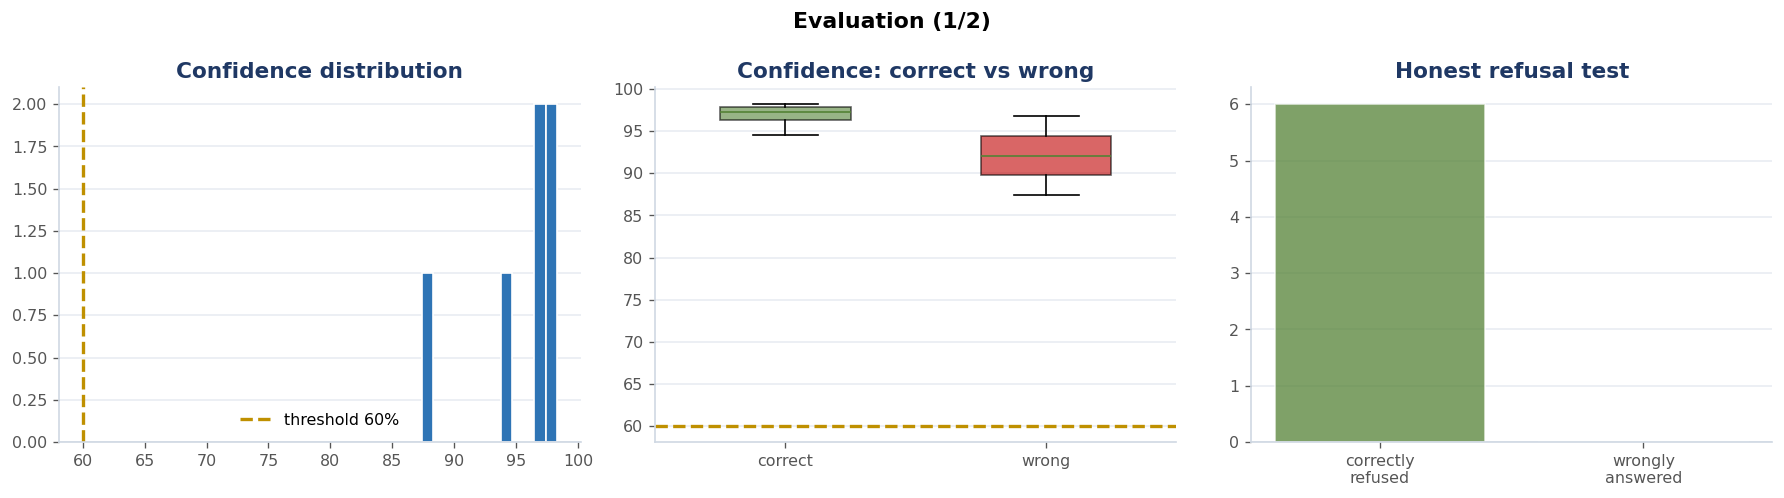

In [ ]:
#  GRAPHS 1–3
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
conf_vals = results['confidence'].dropna()
axes[0].hist(conf_vals, bins=12, color=BLUE, edgecolor='white')
axes[0].axvline(CONF_THRESHOLD, color=AMBER, ls='--', lw=2, label=f'threshold {CONF_THRESHOLD}%')
axes[0].set_title("Confidence distribution", fontweight='bold', color=NAVY); axes[0].legend()

groups = [ans[ans['correct']]['confidence'].dropna(),
          ans[~ans['correct'] & ~ans['refused']]['confidence'].dropna()]
bp = axes[1].boxplot([g if len(g) else [0] for g in groups],
                     tick_labels=['correct','wrong'], patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [GREEN, "#C00000"]): patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1].axhline(CONF_THRESHOLD, color=AMBER, ls='--', lw=2)
axes[1].set_title("Confidence: correct vs wrong", fontweight='bold', color=NAVY)

counts = [int(una['refused'].sum()), int((~una['refused']).sum())]
axes[2].bar(['correctly\nrefused','wrongly\nanswered'], counts,
            color=[GREEN, "#C00000"], edgecolor='white', alpha=0.75)
axes[2].set_title("Honest refusal test", fontweight='bold', color=NAVY)
plt.suptitle("Evaluation (1/2)", fontweight='bold'); plt.tight_layout(); plt.show()

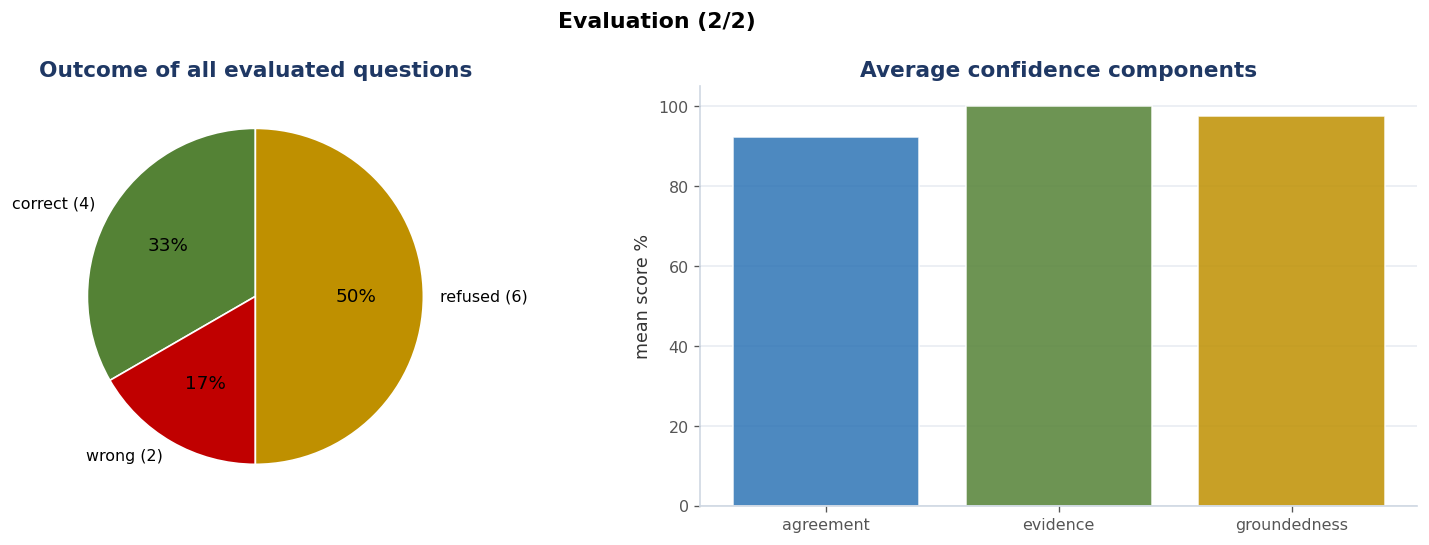

In [ ]:
#  GRAPHS 4–5: outcome pie + component breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
answered_ok  = int((ans['correct'] & ~ans['refused']).sum())
answered_bad = int((~ans['correct'] & ~ans['refused']).sum())
refused_all  = int(results['refused'].sum())
axes[0].pie([answered_ok, answered_bad, refused_all],
            labels=[f'correct ({answered_ok})', f'wrong ({answered_bad})', f'refused ({refused_all})'],
            colors=[GREEN, "#C00000", AMBER], autopct='%1.0f%%',
            wedgeprops={'edgecolor':'white'}, startangle=90)
axes[0].set_title("Outcome of all evaluated questions", fontweight='bold', color=NAVY)

comp = ans[ans['confidence'].notna()][['agreement','evidence','groundedness']].mean()
axes[1].bar(comp.index, comp.values, color=[BLUE, GREEN, AMBER], edgecolor='white', alpha=0.85)
axes[1].set_ylabel("mean score %")
axes[1].set_title("Average confidence components", fontweight='bold', color=NAVY)
plt.suptitle("Evaluation (2/2)", fontweight='bold'); plt.tight_layout(); plt.show()

,Method,Mean,Std,Range,Interpretation
0,3-component (my method),95.3%,4.1,87–98%,Spreads scores → separates good from bad
1,Verbalised (baseline),97.5%,2.7,95–100%,"Clusters high → overconfident (Xiong et al., 2..."


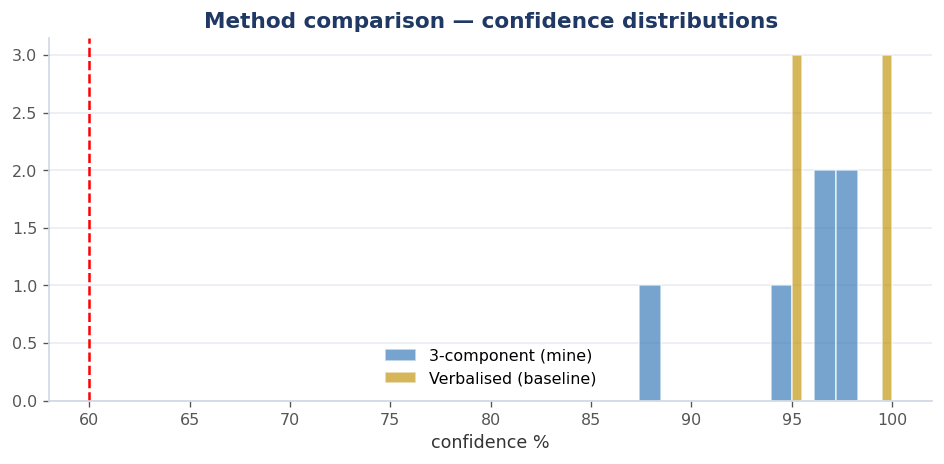

CPU times: user 885 ms, sys: 25.4 ms, total: 910 ms
Wall time: 40.1 s


In [ ]:
%%time
#  METHOD COMPARISON: 3-component (mine) vs verbalised baseline
import re as _re2, time

def verbalised_confidence(question, parents):
    prompt = (build_prompt(question, parents)
              + "\n\nAfter your answer, on a new final line write exactly: Confidence: X%")
    out = llm_primary.invoke(prompt).content
    m = _re2.search(r'[Cc]onfidence:\s*(\d{1,3})', out)
    return min(int(m.group(1)), 100) if m else None

verb = []
for q, gold in test_answerable[:8]:
    parents, _ = retrieve(q)
    v = verbalised_confidence(q, parents)
    if v is not None: verb.append(v)
    time.sleep(0.5)

sc = ans['confidence'].dropna()
display(pd.DataFrame({
    "Method": ["3-component (my method)", "Verbalised (baseline)"],
    "Mean": [f"{sc.mean():.1f}%", f"{pd.Series(verb).mean():.1f}%"],
    "Std":  [f"{sc.std():.1f}", f"{pd.Series(verb).std():.1f}"],
    "Range":[f"{sc.min():.0f}–{sc.max():.0f}%", f"{min(verb):.0f}–{max(verb):.0f}%"],
    "Interpretation": ["Spreads scores → separates good from bad",
                       "Clusters high → overconfident (Xiong et al., 2024)"]}))

plt.figure(figsize=(8, 4))
plt.hist(sc, bins=10, alpha=0.65, label='3-component (mine)', color=BLUE, edgecolor='white')
plt.hist(verb, bins=10, alpha=0.65, label='Verbalised (baseline)', color=AMBER, edgecolor='white')
plt.axvline(CONF_THRESHOLD, color='red', ls='--', lw=1.5)
plt.title("Method comparison — confidence distributions", fontweight='bold', color=NAVY)
plt.xlabel("confidence %"); plt.legend(); plt.tight_layout(); plt.show()

,Confidence bin,Answers,Actually correct
0,0–49%,0,—
1,50–69%,0,—
2,70–84%,0,—
3,85–100%,6,67%


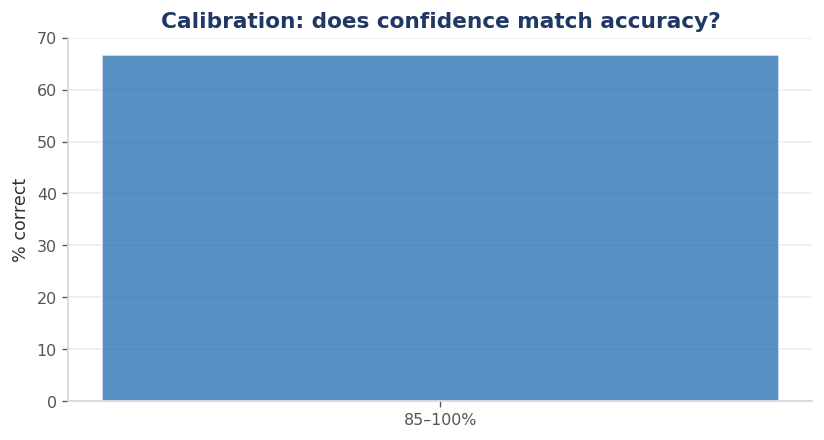

In [ ]:
#  Calibration table + chart
bins = [(0,50),(50,70),(70,85),(85,101)]
rows, xs, ys = [], [], []
for lo, hi in bins:
    grp = ans[(ans['confidence'] >= lo) & (ans['confidence'] < hi)]
    acc = grp['correct'].mean()*100 if len(grp) else None
    rows.append({"Confidence bin": f"{lo}–{hi-1}%", "Answers": len(grp),
                 "Actually correct": f"{acc:.0f}%" if acc is not None else "—"})
    if acc is not None: xs.append(f"{lo}–{hi-1}%"); ys.append(acc)
display(pd.DataFrame(rows))
if xs:
    plt.figure(figsize=(7, 3.8))
    plt.bar(xs, ys, color=BLUE, edgecolor='white', alpha=0.8)
    plt.title("Calibration: does confidence match accuracy?", fontweight='bold', color=NAVY)
    plt.ylabel("% correct"); plt.tight_layout(); plt.show()

## Part 13 — Export the Knowledge Base

In [ ]:
import shutil, os
os.makedirs("rag_assets", exist_ok=True)
shutil.copytree("faiss_index_medquad", "rag_assets/faiss_index_medquad", dirs_exist_ok=True)
shutil.copy("parents.pkl", "rag_assets/parents.pkl")
shutil.make_archive("rag_assets", "zip", ".", "rag_assets")
print("✅ Saved: rag_assets.zip", f"({os.path.getsize('rag_assets.zip')//(1024*1024)} MB)")
from google.colab import files
files.download("rag_assets.zip")

✅ Saved: rag_assets.zip (105 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🚀 Part 14 — Launch the Professional GUI
Runs the Streamlit app and prints a public link. Run the whole notebook first, and make sure `app.py` is in `My Drive/Final Project`.

In [ ]:
# LAUNCH THE GUI
!pip install -q streamlit
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

import os, shutil, time, re, urllib.request
from google.colab import drive

assert os.path.isdir('faiss_index_medquad'), "Run the whole notebook first - index missing."
assert os.path.exists('parents.pkl'),        "Run the whole notebook first - parents.pkl missing."

drive.mount('/content/drive')
APP = '/content/drive/MyDrive/Final Project/app.py'
assert os.path.exists(APP), "app.py not found in My Drive/Final Project - upload it there."
shutil.copy(APP, 'app.py')

os.makedirs('rag_assets', exist_ok=True)
shutil.copytree('faiss_index_medquad', 'rag_assets/faiss_index_medquad', dirs_exist_ok=True)
shutil.copy('parents.pkl', 'rag_assets/parents.pkl')

os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/secrets.toml', 'w') as f:
    f.write(f'GROQ_API_KEY = "{GROQ_API_KEY}"\n')

get_ipython().system_raw('streamlit run app.py --server.port 8501 --server.headless true '
                         '--server.enableCORS false --server.enableXsrfProtection false &> streamlit.log &')
ok = False
for _ in range(60):
    try:
        urllib.request.urlopen('http://localhost:8501/_stcore/health', timeout=2); ok = True; break
    except Exception: time.sleep(2)
if not ok:
    print("Streamlit did not start. Log tail:\n"); print(open('streamlit.log').read()[-3000:])
else:
    get_ipython().system_raw('./cloudflared tunnel --url http://localhost:8501 --no-autoupdate &> tunnel.log &')
    url = None
    for _ in range(30):
        m = re.search(r'https://[-a-z0-9]+\.trycloudflare\.com', open('tunnel.log').read())
        if m: url = m.group(0); break
        time.sleep(2)
    print("\nGUI IS RUNNING - open this link:\n\n    " + url +
          "\n\n(Stays alive after this cell finishes. Re-run for a new link.)"
          if url else "Tunnel failed:\n" + open('tunnel.log').read()[-2000:])

cloudflared: Text file busy
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

GUI IS RUNNING - open this link:

    https://ratings-solomon-speakers-retirement.trycloudflare.com

(Stays alive after this cell finishes. Re-run for a new link.)
